In [2]:
import pandas as pd
import matplotlib.pyplot as plt

"""Dataset loading and understanding"""

data = pd.read_csv('train.csv')
print(data.head())

# Display basic information about the dataset
print(f"Dataset Info:\n{data.info()}\n")

# Display summary statistics
print(f"Summary Statistics:\n{data.describe()}\n")

# Check for missing values
print(f"Missing Values:\n{data.isnull().sum()}\n")
print(f"Missing Values Percentage:\n{(data.isnull().sum() / len(data)) * 100}\n")
#--here there are missing values in 8 columns, we will handle them later 


C:\Users\Adesh Srivastava\AppData\Local\Temp\ipykernel_24892\3120291903.py:6: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('train.csv')


       ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      19114.12            1824.843333                  3  ...           _   
1      19114.12                    NaN                  3  ...        Good   
2      19114.12                    NaN                  3  ...        Good   
3      19114.12                    NaN                  3  ...        Good   
4      19114.12            1824.843333                  3  ...        Good   

   Outstanding_Debt Credit_Utilization_Ratio     C

In [3]:
"""Data cleaning and preprocessing"""

#Here we will remove the unnecessary columns like ID,Customer_ID and Name

data = data.drop(['ID', 'Customer_ID', 'Name'], axis=1)

In [4]:
# Converting object columns to appropriate types: nullable integers or categories

# Columns that are numeric but currently read as object and should be integers
int_cols = ['Age', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan',
            'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries']

# Columns that are categorical but currently read as object
cat_cols = ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
            'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']

for column in data.columns:
    if data[column].dtype == 'object':
        if column in int_cols:
            # use pandas nullable integer dtype to preserve missing values
            data[column] = pd.to_numeric(data[column], errors='coerce').astype('Int64')
        elif column in cat_cols:
            data[column] = data[column].astype('category',errors='ignore')
        else:
            # leave other object columns as categorical by default
            data[column] = data[column].astype('category',errors='ignore')
    else:
        data[column] = data[column].astype('int64',errors='ignore')
        
# Display the updated data types
print(f"Updated Dataset Info:\n{data.info()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Month                     100000 non-null  category
 1   Age                       95061 non-null   Int64   
 2   SSN                       100000 non-null  category
 3   Occupation                100000 non-null  category
 4   Annual_Income             100000 non-null  category
 5   Monthly_Inhand_Salary     84998 non-null   float64 
 6   Num_Bank_Accounts         100000 non-null  int64   
 7   Num_Credit_Card           100000 non-null  int64   
 8   Interest_Rate             100000 non-null  int64   
 9   Num_of_Loan               95215 non-null   Int64   
 10  Type_of_Loan              88592 non-null   category
 11  Delay_from_due_date       100000 non-null  int64   
 12  Num_of_Delayed_Payment    90254 non-null   Int64   
 13  Changed_Credit_Limit      1000

In [5]:
#now handling msiing values for both categorical and numerical columns we will use KNN imputer for numerical columns and mode imputation for categorical columns

from sklearn.impute import KNNImputer
# Separate numerical and categorical columns
num_cols = data.select_dtypes(include=['Int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['category']).columns
# Impute numerical columns using KNN imputer
imputer = KNNImputer(n_neighbors=5)
data[num_cols] = imputer.fit_transform(data[num_cols])
# Impute categorical columns using mode imputation
for column in cat_cols:
    data[column] = data[column].fillna(data[column].mode()[0])
# Verify that there are no more missing values
print(f"Missing Values After Imputation:\n{data.isnull().sum()}\n")

Missing Values After Imputation:
Month                       0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64



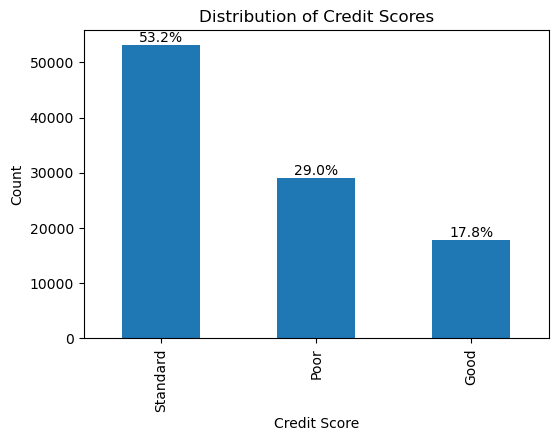

In [6]:
"""Performing EDA"""

#Analyzing the target variable distribution with percentage on the top of the bars
plt.figure(figsize=(6, 4))
data['Credit_Score'].value_counts().plot(kind='bar')
plt.title('Distribution of Credit Scores')
plt.xlabel('Credit Score')
plt.ylabel('Count')
# Adding percentage labels on top of the bars
total = len(data)
for p in plt.gca().patches:
    percentage = f'{(p.get_height() / total) * 100:.1f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.show()


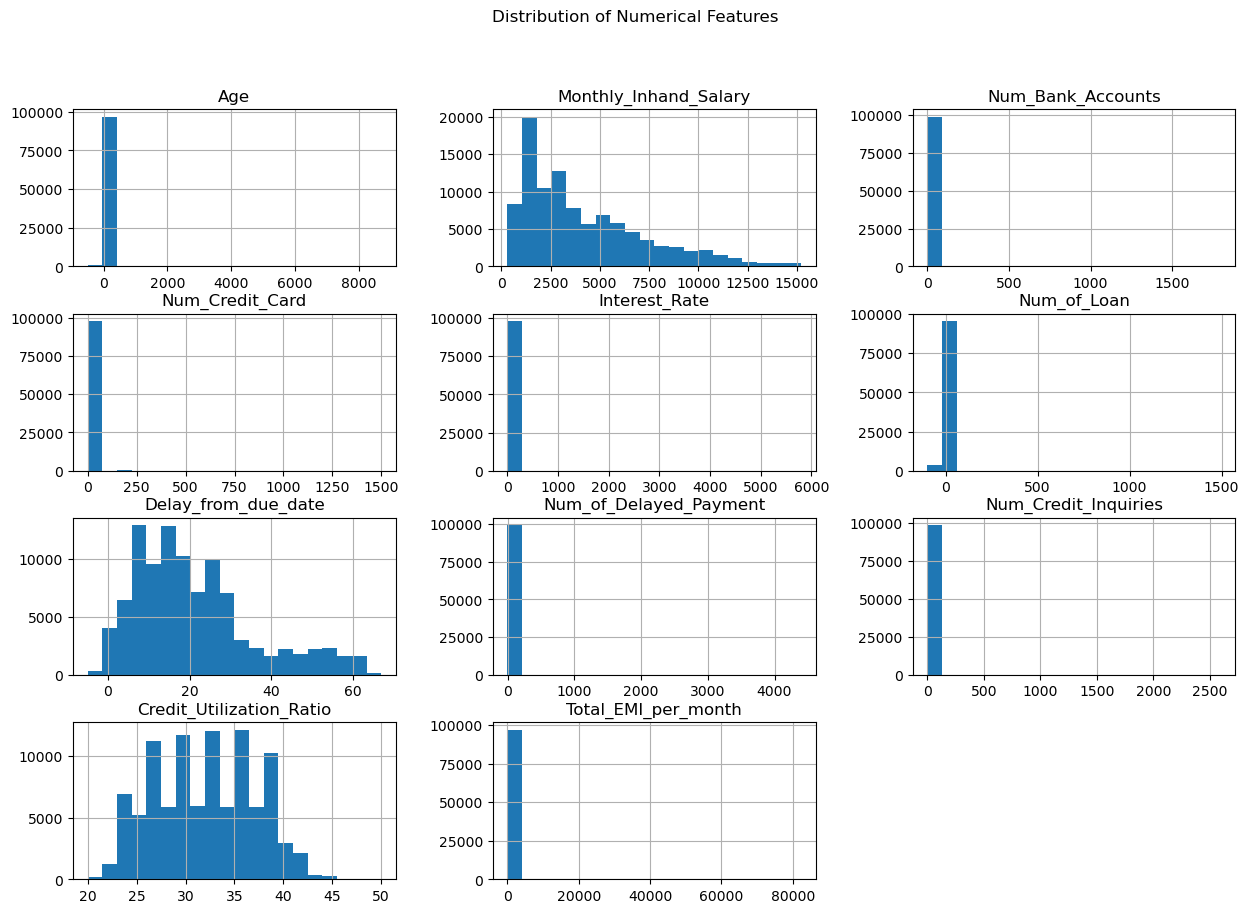

<Figure size 600x400 with 0 Axes>

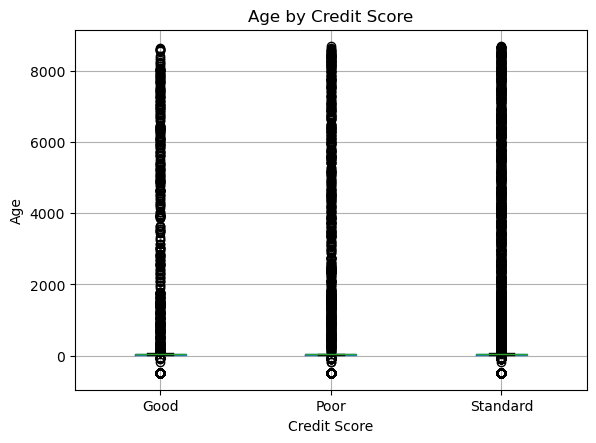

<Figure size 600x400 with 0 Axes>

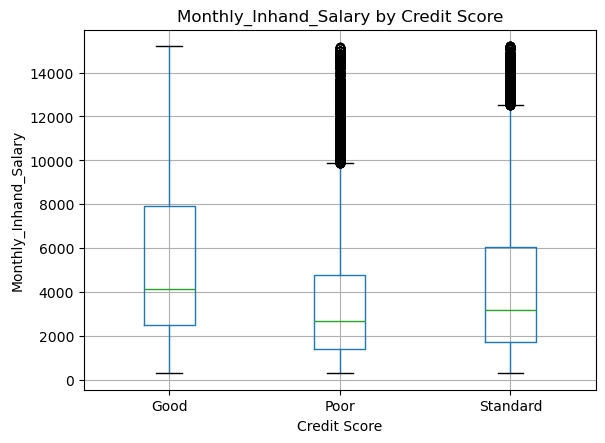

<Figure size 600x400 with 0 Axes>

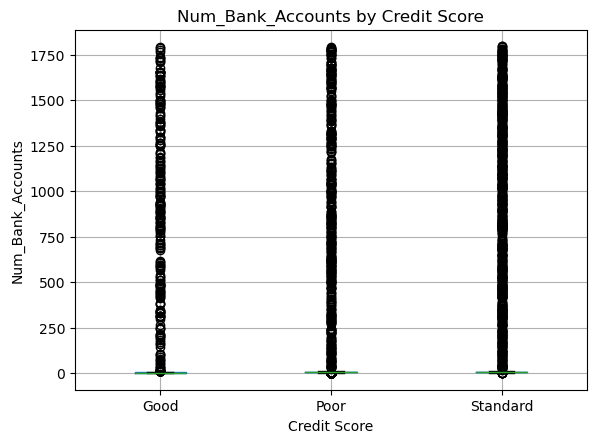

<Figure size 600x400 with 0 Axes>

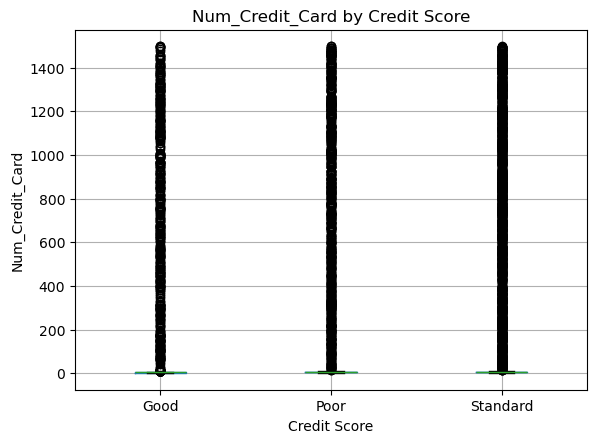

<Figure size 600x400 with 0 Axes>

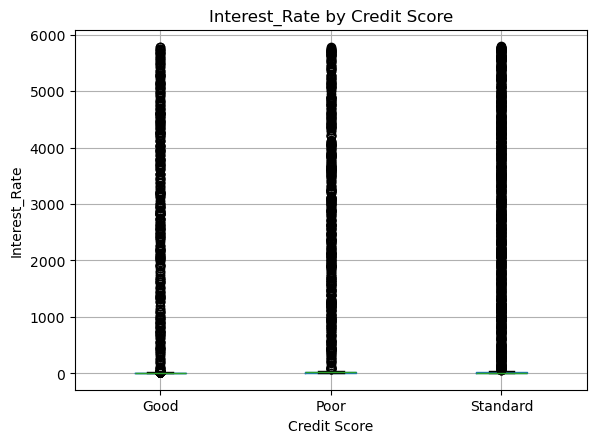

<Figure size 600x400 with 0 Axes>

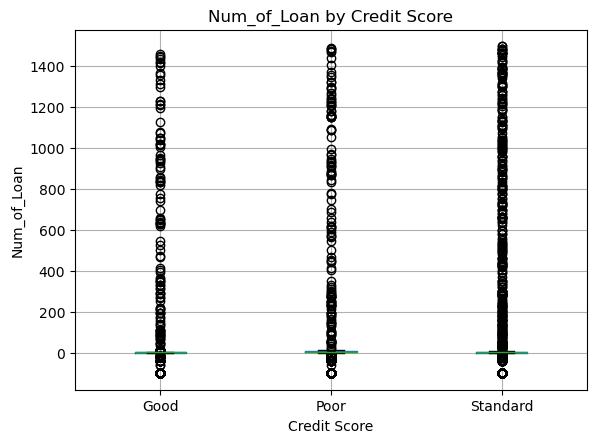

<Figure size 600x400 with 0 Axes>

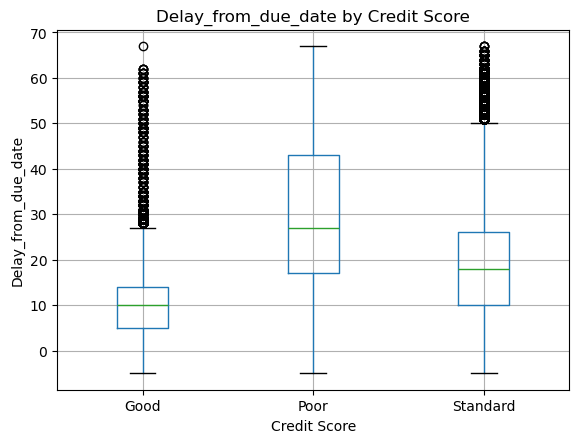

<Figure size 600x400 with 0 Axes>

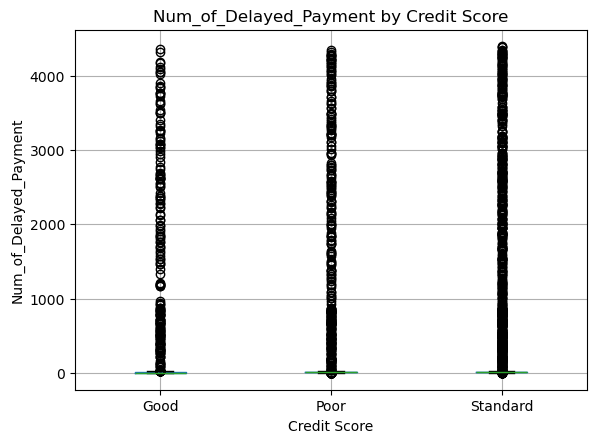

<Figure size 600x400 with 0 Axes>

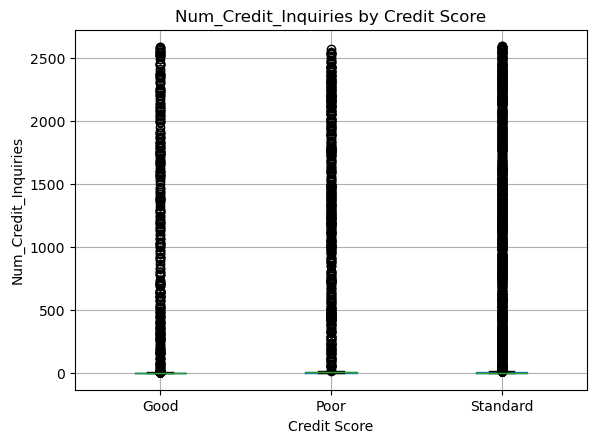

<Figure size 600x400 with 0 Axes>

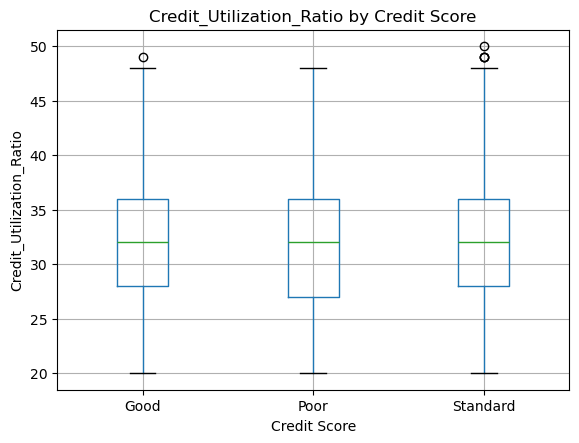

<Figure size 600x400 with 0 Axes>

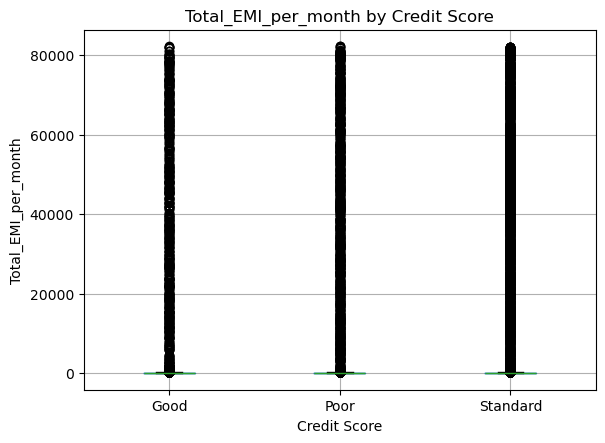

In [7]:
#Analyzing the distribution of numerical features with histograms
num_cols = data.select_dtypes(include=['Int64', 'float64']).columns
data[num_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle('Distribution of Numerical Features')
plt.show()

#Analyzing the relationship between numerical features and the target variable using box plots
for column in num_cols:
    plt.figure(figsize=(6, 4))
    data.boxplot(column=column, by='Credit_Score')
    plt.title(f'{column} by Credit Score')
    plt.suptitle('')
    plt.xlabel('Credit Score')
    plt.ylabel(column)
    plt.show()

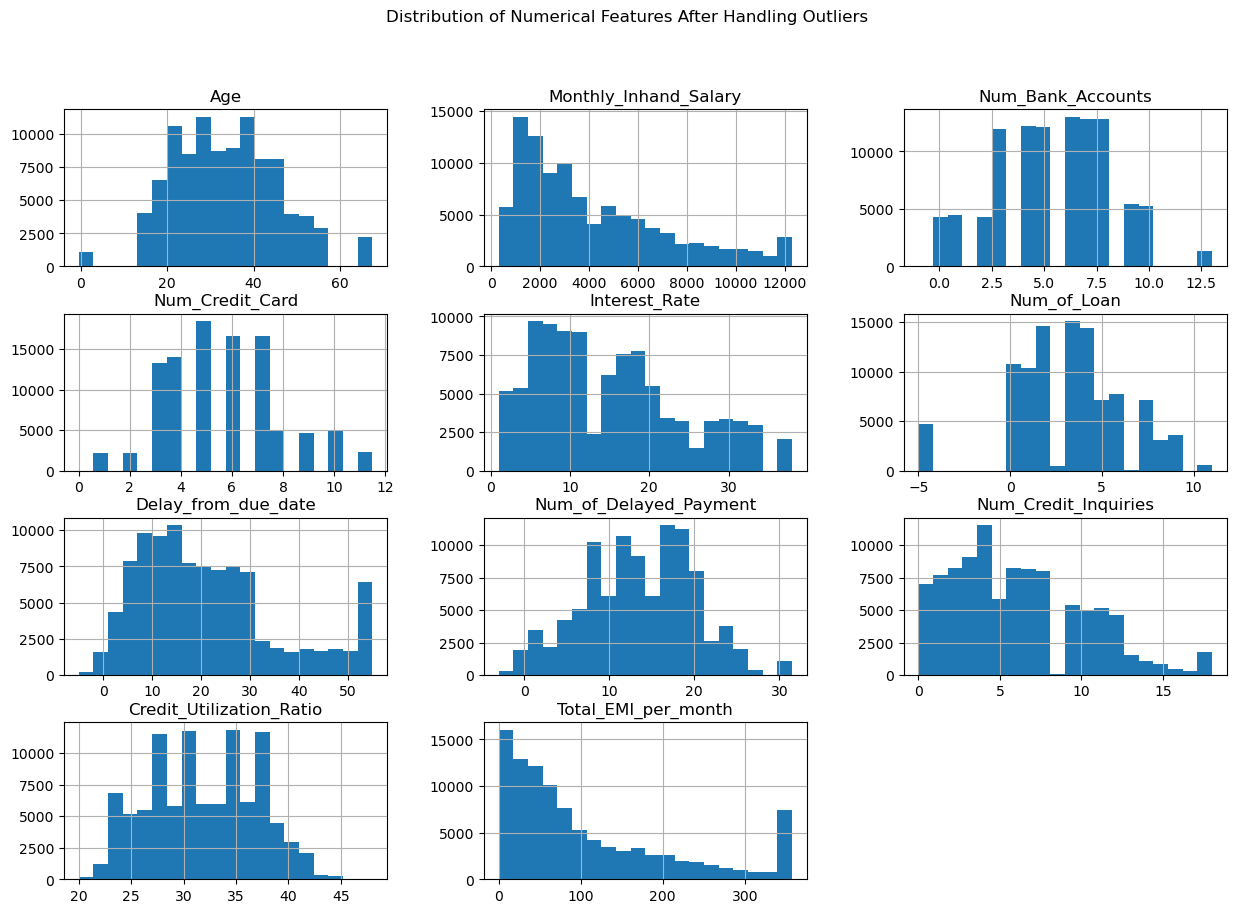

<Figure size 600x400 with 0 Axes>

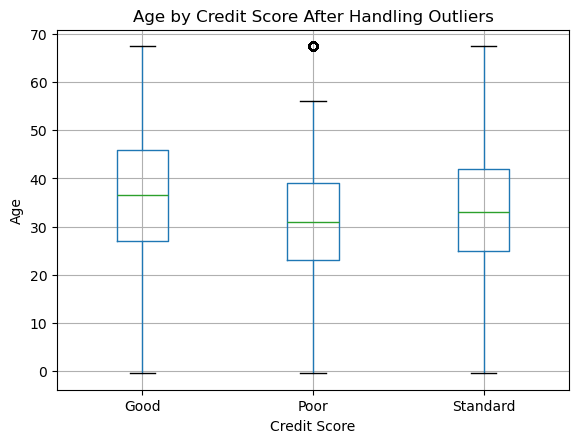

<Figure size 600x400 with 0 Axes>

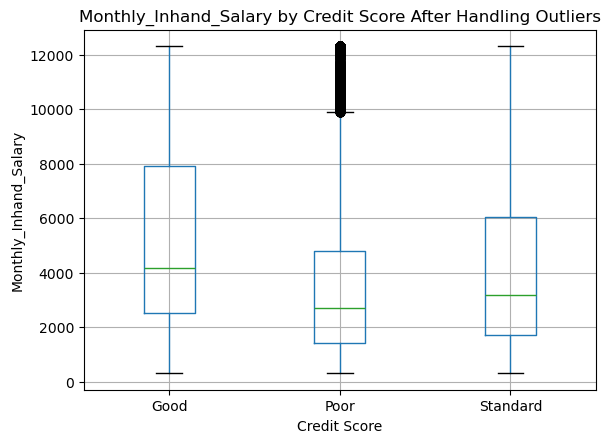

<Figure size 600x400 with 0 Axes>

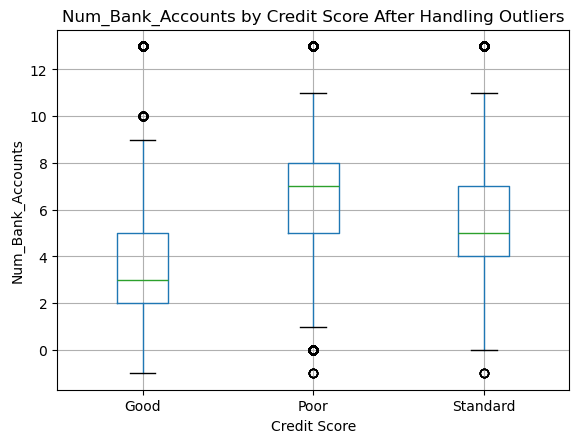

<Figure size 600x400 with 0 Axes>

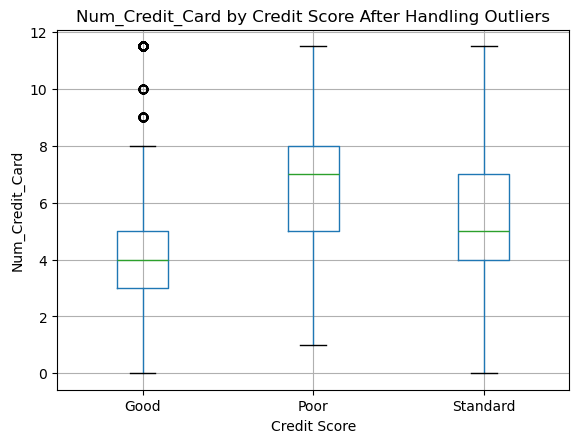

<Figure size 600x400 with 0 Axes>

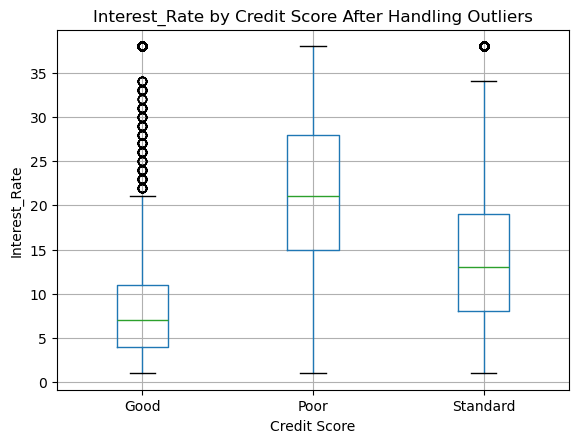

<Figure size 600x400 with 0 Axes>

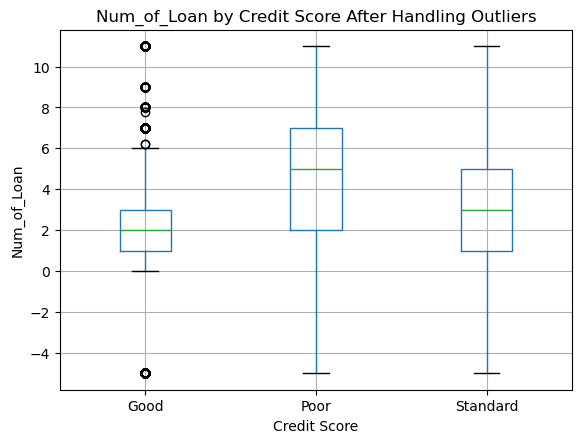

<Figure size 600x400 with 0 Axes>

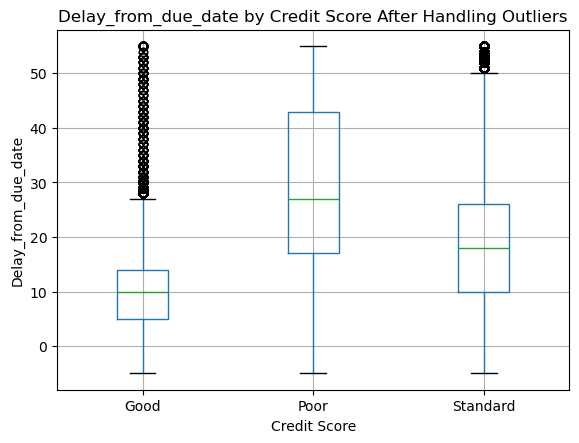

<Figure size 600x400 with 0 Axes>

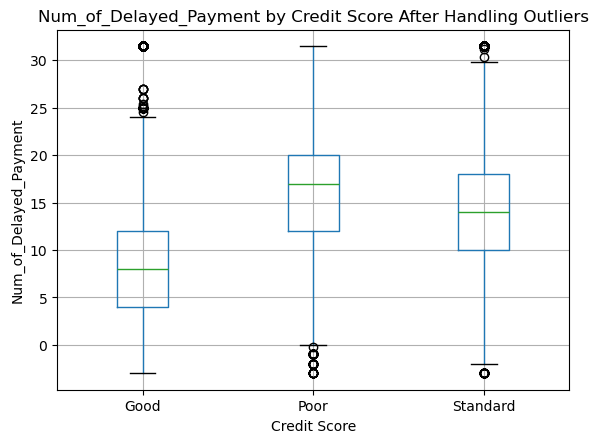

<Figure size 600x400 with 0 Axes>

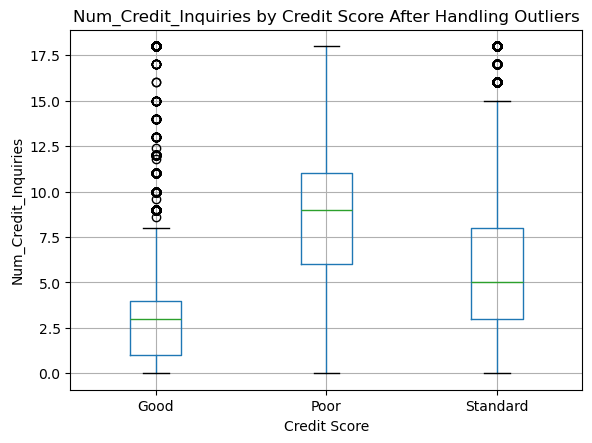

<Figure size 600x400 with 0 Axes>

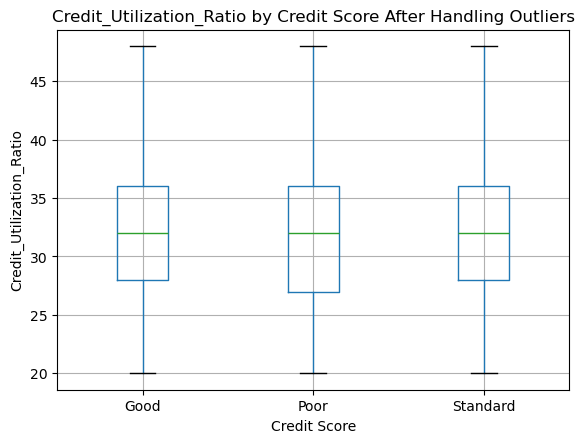

<Figure size 600x400 with 0 Axes>

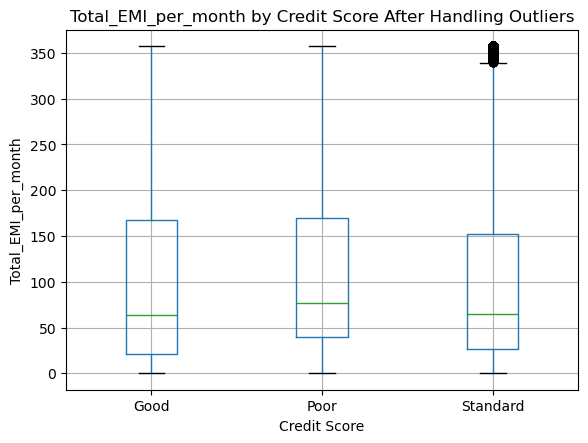

In [8]:
"""So From the above visualization, we can see that there are a lot of outliers. And we need to handle them. We will use the IQR method to handle the outliers. We will cap the outliers at the 1st and 99th percentile. """

#using IQR method to handle outliers
for column in num_cols:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Cap the outliers
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    
#checking the distribution of numerical features after handling outliers
data[num_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle('Distribution of Numerical Features After Handling Outliers')
plt.show()

#using box plots to check the relationship between numerical features and the target variable after handling outliers
for column in num_cols:
    plt.figure(figsize=(6, 4))
    data.boxplot(column=column, by='Credit_Score')
    plt.title(f'{column} by Credit Score After Handling Outliers')
    plt.suptitle('')
    plt.xlabel('Credit Score')
    plt.ylabel(column)
    plt.show()


In [9]:
"""Since after using the IKR, we can see that there are still some outliers Present in the data, so we will use winsorization technique. """

data[num_cols] = data[num_cols].apply(lambda x: x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99)))

"""Checking the data whether it is precise and correct after cleaning """

print(data.head())
print(f"Dataset Info After Cleaning:\n{data.info()}\n")
print(f"Summary Statistics After Cleaning:\n{data.describe()}\n")
print(f"Missing Values After Cleaning:\n{data.isnull().sum()}\n")
print(f"Unique Values in Categorical Columns After Cleaning:\n{data[cat_cols].nunique()}\n")
print(f"Unique Values in Numerical Columns After Cleaning:\n{data[num_cols].nunique()}\n")

      Month   Age          SSN Occupation Annual_Income  \
0   January  23.0  821-00-0265  Scientist      19114.12   
1  February  23.0  821-00-0265  Scientist      19114.12   
2     March  -0.5  821-00-0265  Scientist      19114.12   
3     April  23.0  821-00-0265  Scientist      19114.12   
4       May  23.0  821-00-0265  Scientist      19114.12   

   Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  \
0            1824.843333                3.0              4.0            3.0   
1            4132.353333                3.0              4.0            3.0   
2            2965.375167                3.0              4.0            3.0   
3            3683.582667                3.0              4.0            3.0   
4            1824.843333                3.0              4.0            3.0   

   Num_of_Loan  ... Credit_Mix  Outstanding_Debt  Credit_Utilization_Ratio  \
0          4.0  ...          _            809.98                      26.0   
1          4.0

In [10]:
"""Here we can still see that there are some negative minimum values in some of the columns, which is not useful. We will handle them by replacing the negative values with the median of the respective columns. """

for column in num_cols:
    median_val = data[column].median()  # compute ONCE outside lambda (faster)
    data[column] = data[column].apply(
        lambda x: median_val if (pd.isna(x) or x < 0) else x
    )

print(data[num_cols].isnull().sum())  # should show 0s now
    
print(f"Summary Statistics After Handling Negative Values:\n{data.describe()}\n")
print(data.info())

Age                         0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Num_Credit_Inquiries        0
Credit_Utilization_Ratio    0
Total_EMI_per_month         0
dtype: int64
Summary Statistics After Handling Negative Values:
                 Age  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  100000.000000          100000.000000      100000.000000   
mean       34.083827            4171.587936           5.468200   
std        11.630562            3037.504876           2.719004   
min        14.000000             546.809167           0.000000   
25%        25.000000            1660.866667           3.000000   
50%        33.000000            3169.576667           6.000000   
75%        42.000000            5921.000000           7.000000   
max        67.500000           12311.200000          13.000000   

       Num_

In [11]:
#As we can see, the number of credits is mentioned as a float by IQR, so we need to convert it and round off to an integer because a person can't have a floating number of credits. 

data['Num_Credit_Inquiries'] = data['Num_Credit_Inquiries'].round().astype('Int64',errors='ignore')

print(f"Summary Statistics After Rounding Num_Credit_Inquiries:\n{data.describe()}\n")

print(data.columns)

Summary Statistics After Rounding Num_Credit_Inquiries:
                 Age  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  100000.000000          100000.000000      100000.000000   
mean       34.083827            4171.587936           5.468200   
std        11.630562            3037.504876           2.719004   
min        14.000000             546.809167           0.000000   
25%        25.000000            1660.866667           3.000000   
50%        33.000000            3169.576667           6.000000   
75%        42.000000            5921.000000           7.000000   
max        67.500000           12311.200000          13.000000   

       Num_Credit_Card  Interest_Rate    Num_of_Loan  Delay_from_due_date  \
count    100000.000000  100000.000000  100000.000000        100000.000000   
mean          5.668955      15.008950       3.540560            20.909770   
std           2.228701       9.263065       2.411855            14.406884   
min           1.000000       1.000000    

In [12]:
"""Cleaning some of the categorical variables, dropping some irrelevant ones, and converting the data type of some categorical to the desired data type which has most unique values. """

#Here we will drop the column. SSN, because it has a lot of unique values and it will SSN, because it has A lot of unique values which can cause overfitting and it has no predictive meaning. 

from xml.parsers.expat import errors

# Drop SSN if present (avoid KeyError if already removed)
data = data.drop(['SSN'], axis=1, errors='ignore')

#Now here we will convert the data type of annual income. Outstanding depth Amount invested monthly Monthly Balance to float because they have a lot of unique values and they  are numerical in nature.

data['Annual_Income'] = pd.to_numeric(
    data['Annual_Income'],
    errors='coerce'
)
data['Outstanding_Debt'] = pd.to_numeric(
    data['Outstanding_Debt'],
    errors='coerce'
)
data['Amount_invested_monthly'] = pd.to_numeric(
    data['Amount_invested_monthly'],
    errors='coerce'
)
data['Monthly_Balance'] = pd.to_numeric(
    data['Monthly_Balance'],
    errors='coerce'
)
data['Changed_Credit_Limit'] = pd.to_numeric(
    data['Changed_Credit_Limit'],   
    errors='coerce'
)

In [13]:
cat_cols = data.select_dtypes(include=['category']).columns
print(f"Categorical Columns After Cleaning:\n{cat_cols}\n")

num_cols = data.select_dtypes(include=['Int64', 'float64']).columns
print(f"Numerical Columns After Cleaning:\n{num_cols}\n")

print(data.info())
print(f'categorical columns unique values:\n{data[cat_cols].nunique()}\n')
print(f'numerical columns unique values:\n{data[num_cols].nunique()}\n')
print(f'summary statistics after final cleaning:\n{data.describe()}\n')

Categorical Columns After Cleaning:
Index(['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
       'Credit_History_Age', 'Payment_of_Min_Amount', 'Payment_Behaviour',
       'Credit_Score'],
      dtype='object')

Numerical Columns After Cleaning:
Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Month                     100000 non-null  category
 1   Age                       100000 non-null  float64 
 2   Occupation 

In [14]:
print(data.head())
print(data.info())

      Month   Age Occupation  Annual_Income  Monthly_Inhand_Salary  \
0   January  23.0  Scientist       19114.12            1824.843333   
1  February  23.0  Scientist       19114.12            4132.353333   
2     March  33.0  Scientist       19114.12            2965.375167   
3     April  23.0  Scientist       19114.12            3683.582667   
4       May  23.0  Scientist       19114.12            1824.843333   

   Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan  \
0                3.0              4.0            3.0          4.0   
1                3.0              4.0            3.0          4.0   
2                3.0              4.0            3.0          4.0   
3                3.0              4.0            3.0          4.0   
4                3.0              4.0            3.0          4.0   

                                        Type_of_Loan  ...  Credit_Mix  \
0  Auto Loan, Credit-Builder Loan, Personal Loan,...  ...           _   
1  Auto Loan, Cred

In [15]:
# Debt-to-Income Ratio — classic credit feature
data['Debt_to_Income'] = data['Outstanding_Debt'] / (data['Annual_Income'] + 00.1)

# EMI burden — what % of monthly salary goes to EMI
data['EMI_to_Salary_Ratio'] = data['Total_EMI_per_month'] / (data   ['Monthly_Inhand_Salary'] + 00.1)

# Savings rate — how much they invest vs earn
data['Savings_Rate'] = data['Amount_invested_monthly'] / (data['Monthly_Inhand_Salary'] + 00.1)

# Payment stress — delayed payments per loan
data['Delay_per_Loan'] = data['Num_of_Delayed_Payment'] / (data['Num_of_Loan'] + 00.1)

# Credit card utilization pressure
data['Cards_per_Bank'] = data['Num_Credit_Card'] / (data['Num_Bank_Accounts'] + 00.1)

print(data.describe())

                 Age  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  100000.000000   9.302000e+04          100000.000000      100000.000000   
mean       34.083827   1.785790e+05            4171.587936           5.468200   
std        11.630562   1.442878e+06            3037.504876           2.719004   
min        14.000000   7.005930e+03             546.809167           0.000000   
25%        25.000000   1.943560e+04            1660.866667           3.000000   
50%        33.000000   3.755074e+04            3169.576667           6.000000   
75%        42.000000   7.284338e+04            5921.000000           7.000000   
max        67.500000   2.419806e+07           12311.200000          13.000000   

       Num_Credit_Card  Interest_Rate    Num_of_Loan  Delay_from_due_date  \
count    100000.000000  100000.000000  100000.000000        100000.000000   
mean          5.668955      15.008950       3.540560            20.909770   
std           2.228701       9.263065  

In [16]:
"""First, we will encode the categorical data into proper encoding so that there could be a correlation, especially for the target variable 0, 1, 2 as a classification. """

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

import re

#1. Convert Credit_History_Age → Credit_History_Months 
def parse_credit_age(val):
    y = re.search(r'(\d+)\s*Year', str(val))
    m = re.search(r'(\d+)\s*Month', str(val))
    return (int(y.group(1)) if y else 0) * 12 + (int(m.group(1)) if m else 0)

data['Credit_History_Months'] = data['Credit_History_Age'].apply(parse_credit_age)
data.drop(columns=['Credit_History_Age'], inplace=True)

# 2. Drop columns that should not be in X 
cols_to_drop = ['Month', 'Type_of_Loan', 'Credit_Score']  # Month and Type_of_Loan are not predictive, Credit_Score is target

X = data.drop(columns=[c for c in cols_to_drop if c in data.columns])
y = data['Credit_Score']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Classes: {label_encoder.classes_}")  # Good=0, Poor=1, Standard=2

# Define encoding strategy per column ──

# OrdinalEncoder — columns with natural order or high cardinality
ordinal_cols = [
    'Credit_Mix',           # Bad < Standard < Good
    'Payment_of_Min_Amount', # No < NM < Yes
    'Credit_History_Months', # 404 unique — treat as ordered number
]

# OneHotEncoder — only LOW cardinality columns (< 20 unique)
onehot_cols = [
    'Occupation',        # 16 unique 
    'Payment_Behaviour', # 7 unique  
]

# Numerical — pass as-is (pipeline will scale later)
num_cols_X = [c for c in X.select_dtypes(
    include=['float64','int64','Int64']
).columns.tolist()]

remove_cols = [
    'EMI_to_Salary_Ratio',
    'Savings_Rate',
    'Delay_per_Loan',
    'Cards_per_Bank',
    # weak correlation features — exclude before encoding so preprocessor matches model
    'Annual_Income',
    'Credit_Utilization_Ratio',
    'Debt_to_Income',
]

num_cols_X = [c for c in num_cols_X if c not in remove_cols]

print(f"Numerical: {len(num_cols_X)} cols")
print(f"OrdinalEncoded: {len(ordinal_cols)} cols")
print(f"OneHotEncoded: {len(onehot_cols)} cols")


preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols_X),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value',
                           unknown_value=-1), ordinal_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore',
                          sparse_output=False), onehot_cols),
])

X_encoded = preprocessor.fit_transform(X)
print(f"X shape: {X_encoded.shape}")  
print(f"y shape: {y_encoded.shape}")

print(f'statistics of encoded features:\n{pd.DataFrame(X_encoded).describe()}\n')


Classes: ['Good' 'Poor' 'Standard']
Numerical: 17 cols
OrdinalEncoded: 3 cols
OneHotEncoded: 2 cols
X shape: (100000, 43)
y shape: (100000,)
statistics of encoded features:
              0         1         2         3         4         5         6   \
count   100000.0  93020.00  100000.0  100000.0  100000.0  100000.0  100000.0   
unique     208.0  13437.00   26310.0      13.0      12.0      35.0      46.0   
top         33.0  17273.83   12311.2       6.0       5.0       8.0       3.0   
freq      3571.0     16.00    1993.0   13001.0   18459.0    5012.0   19403.0   

              7         8         9   ...        33        34        35  \
count   100000.0  100000.0  97909.00  ...  100000.0  100000.0  100000.0   
unique      56.0     142.0   4375.00  ...       2.0       2.0       2.0   
top         55.0      19.0      8.22  ...       0.0       0.0       0.0   
freq      4562.0    5433.0    133.00  ...   93785.0   94115.0   92938.0   

              36        37        38        39    

In [17]:
#Now we will use some correlation to actually see the relation between each numerical feature and which to drop. 

print("Correlation with target variable:")
for i, col in enumerate(num_cols_X):
    corr = pd.Series(X_encoded[:, i]).corr(pd.Series(y_encoded))
    print(f"{col}: {corr:.4f}")

Correlation with target variable:
Age: -0.0540
Annual_Income: 0.0025
Monthly_Inhand_Salary: -0.0769
Num_Bank_Accounts: 0.1665
Num_Credit_Card: 0.1029
Interest_Rate: 0.1094
Num_of_Loan: 0.0615
Delay_from_due_date: 0.1009
Num_of_Delayed_Payment: 0.1907
Changed_Credit_Limit: 0.1886
Num_Credit_Inquiries: 0.0626
Outstanding_Debt: 0.0372
Credit_Utilization_Ratio: -0.0139
Total_EMI_per_month: -0.0322
Amount_invested_monthly: -0.0708
Monthly_Balance: -0.0587
Debt_to_Income: 0.0349


In [20]:
"""Weak features were already excluded from num_cols_X before fitting the preprocessor."""

print(f"Shape after excluding weak features: {X_encoded.shape}")
print(f"Preprocessor output columns: {preprocessor.transform(X.iloc[:1]).shape[1]}")


Shape after dropping weak features: (100000, 40)


In [21]:
"""Now we will train our model on a random forest classifier. We are using Random Forest Classifier as it can handle soft labs really well and it can handle multiple features as well. Further, we will also use grid search, random search, and optinum to find the best results.     """

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(f"Training set shape: {x_train.shape}, {y_train.shape}")

rf = RandomForestClassifier(n_estimators=200, min_samples_split=2, min_samples_leaf=1, max_features='log2', max_depth=None, bootstrap=True, random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
cv_scores = cross_val_score(rf, x_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)

#using ROC-AUC score for multiclass classification
from sklearn.metrics import roc_auc_score
y_prob = rf.predict_proba(x_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print("ROC-AUC Score:", roc_auc)


Training set shape: (80000, 40), (80000,)
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.72      0.73      3566
           1       0.78      0.79      0.79      5799
           2       0.81      0.81      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.77      0.77     20000
weighted avg       0.79      0.79      0.79     20000

Confusion Matrix:
 [[2552   24  990]
 [ 125 4585 1089]
 [ 775 1245 8615]]
Accuracy: 0.7876
F1 Score: 0.787399174767209
Cross-Validation Accuracy Scores: [0.7736875 0.78125   0.7793125 0.7808125 0.7809375]
ROC-AUC Score: 0.9109951759159837


In [22]:
import joblib

# verify preprocessor output matches trained model before saving
assert preprocessor.transform(X.iloc[:1]).shape[1] == rf.n_features_in_, \
    "Preprocessor and model feature counts must match"

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(rf, "credit_scoring_rf_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['credit_scoring_rf_model.pkl']

In [ ]:
"""Now we will perform hyperparameter tuning like random search CV, grid search CV, and Optuna to find the best parameters for the random forest. """

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#1st will use random search CV to find the best parameters for the random forest.
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],  
    'max_depth'        : [10, 15, 20, 25, None], 
    'min_samples_split': [2, 5, 10],           
    'min_samples_leaf' : [1, 2, 4],             
    'max_features'     : ['sqrt', 'log2'],         
    'bootstrap'        : [True]                    
}

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=5, cv=3, verbose=2, random_state=42, n_jobs=1)
random_search.fit(x_train, y_train)
print("Best Parameters from Random Search CV:", random_search.best_params_)
best_rf_random = random_search.best_estimator_
y_pred_random = best_rf_random.predict(x_test)
print("Classification Report (Random Search CV):\n", classification_report(y_test, y_pred_random))
print("Confusion Matrix (Random Search CV):\n", confusion_matrix(y_test, y_pred_random))
print("Accuracy (Random Search CV):", accuracy_score(y_test, y_pred_random))



In [ ]:
print(list(X.columns))

['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Debt_to_Income', 'EMI_to_Salary_Ratio', 'Savings_Rate', 'Delay_per_Loan', 'Cards_per_Bank', 'Credit_History_Months']


In [ ]:
print("Ordinal:", ordinal_cols)
print("OneHot:", onehot_cols)

Ordinal: ['Credit_Mix', 'Payment_of_Min_Amount', 'Credit_History_Months']
OneHot: ['Occupation', 'Payment_Behaviour']


In [ ]:
print(label_encoder.classes_)

['Good' 'Poor' 'Standard']


In [ ]:
import sklearn
print(f"Saving with sklearn version: {sklearn.__version__}")

import joblib
joblib.dump(preprocessor, 'preprocessor.pkl', protocol=2)  # protocol=2 = more compatible
joblib.dump(rf,         'credit_scoring_rf_model.pkl', protocol=2)
joblib.dump(label_encoder, 'label_encoder.pkl', protocol=2)
print(" Resaved with protocol=2")

Saving with sklearn version: 1.6.1
 Resaved with protocol=2


In [ ]:
ohe = preprocessor.named_transformers_['cat']
print(ohe.get_feature_names_out(['Occupation', 'Payment_Behaviour']))

['Occupation_Accountant' 'Occupation_Architect' 'Occupation_Developer'
 'Occupation_Doctor' 'Occupation_Engineer' 'Occupation_Entrepreneur'
 'Occupation_Journalist' 'Occupation_Lawyer' 'Occupation_Manager'
 'Occupation_Mechanic' 'Occupation_Media_Manager' 'Occupation_Musician'
 'Occupation_Scientist' 'Occupation_Teacher' 'Occupation_Writer'
 'Occupation________' 'Payment_Behaviour_!@9#%8'
 'Payment_Behaviour_High_spent_Large_value_payments'
 'Payment_Behaviour_High_spent_Medium_value_payments'
 'Payment_Behaviour_High_spent_Small_value_payments'
 'Payment_Behaviour_Low_spent_Large_value_payments'
 'Payment_Behaviour_Low_spent_Medium_value_payments'
 'Payment_Behaviour_Low_spent_Small_value_payments']


In [ ]:
print(f"Model expects : {rf.n_features_in_} features")
print(f"X columns     : {len(X.columns)}")
print(f"num_cols_X    : {len(num_cols_X)}")
print(f"ordinal_cols  : {len(ordinal_cols)}")
ohe = preprocessor.named_transformers_['cat']
print(f"OHE output    : {len(ohe.get_feature_names_out())} cols")
print(f"Total         : {len(num_cols_X) + len(ordinal_cols) + len(ohe.get_feature_names_out())}")

Model expects : 41 features
X columns     : 26
num_cols_X    : 21
ordinal_cols  : 3
OHE output    : 23 cols
Total         : 47


In [ ]:

# Get exact column names the preprocessor was fitted on
num_transformer = preprocessor.transformers_[0]
ord_transformer = preprocessor.transformers_[1]
cat_transformer = preprocessor.transformers_[2]

print("NUM cols:", num_transformer[2])
print("ORD cols:", ord_transformer[2])
print("CAT cols:", cat_transformer[2])

NUM cols: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Debt_to_Income', 'EMI_to_Salary_Ratio', 'Savings_Rate', 'Delay_per_Loan', 'Cards_per_Bank']
ORD cols: ['Credit_Mix', 'Payment_of_Min_Amount', 'Credit_History_Months']
CAT cols: ['Occupation', 'Payment_Behaviour']


In [ ]:
X_sample = preprocessor.transform(X.iloc[:1])
print(f"Preprocessor output: {X_sample.shape[1]} cols")
print(f"Model expects      : {rf.n_features_in_} features")
assert X_sample.shape[1] == rf.n_features_in_, "Feature mismatch — re-save preprocessor after final fit"
pred = rf.predict(X_sample)
print(f"Sample prediction OK: {label_encoder.inverse_transform(pred)[0]}")

Now produces: 47 cols


In [ ]:
ohe = preprocessor.named_transformers_['cat']
print(ohe.get_feature_names_out())

['Occupation_Accountant' 'Occupation_Architect' 'Occupation_Developer'
 'Occupation_Doctor' 'Occupation_Engineer' 'Occupation_Entrepreneur'
 'Occupation_Journalist' 'Occupation_Lawyer' 'Occupation_Manager'
 'Occupation_Mechanic' 'Occupation_Media_Manager' 'Occupation_Musician'
 'Occupation_Scientist' 'Occupation_Teacher' 'Occupation_Writer'
 'Occupation________' 'Payment_Behaviour_!@9#%8'
 'Payment_Behaviour_High_spent_Large_value_payments'
 'Payment_Behaviour_High_spent_Medium_value_payments'
 'Payment_Behaviour_High_spent_Small_value_payments'
 'Payment_Behaviour_Low_spent_Large_value_payments'
 'Payment_Behaviour_Low_spent_Medium_value_payments'
 'Payment_Behaviour_Low_spent_Small_value_payments']


In [ ]:
print(preprocessor.feature_names_in_)

['Age' 'Occupation' 'Annual_Income' 'Monthly_Inhand_Salary'
 'Num_Bank_Accounts' 'Num_Credit_Card' 'Interest_Rate' 'Num_of_Loan'
 'Delay_from_due_date' 'Num_of_Delayed_Payment' 'Changed_Credit_Limit'
 'Num_Credit_Inquiries' 'Credit_Mix' 'Outstanding_Debt'
 'Credit_Utilization_Ratio' 'Payment_of_Min_Amount' 'Total_EMI_per_month'
 'Amount_invested_monthly' 'Payment_Behaviour' 'Monthly_Balance'
 'Debt_to_Income' 'EMI_to_Salary_Ratio' 'Savings_Rate' 'Delay_per_Loan'
 'Cards_per_Bank' 'Credit_History_Months']


In [ ]:
print(x_train.columns.tolist())

[0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]


In [ ]:
print(list(preprocessor.feature_names_in_))

['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Debt_to_Income', 'EMI_to_Salary_Ratio', 'Savings_Rate', 'Delay_per_Loan', 'Cards_per_Bank', 'Credit_History_Months']
